# 06 — Expected Loss & Credit Policy Economics

## Objective

Translate the experimental default-rate effect into a credit-risk and business decision.

The core credit-risk relationship is:

\[
Expected\ Loss = PD 	imes LGD 	imes EAD
\]

where:

- **PD** = probability of default
- **LGD** = loss given default
- **EAD** = exposure at default

This notebook compares the simulated **Control** and **Treatment** policies and asks:

> **Does the reduction in expected credit loss justify the reduction in approvals?**

> **Important:** LGD and the value of an approved loan are not directly observed in the Lending Club dataset used for this project. Where assumptions are required, they are explicitly labeled and sensitivity analysis is provided.


## 1. Imports and load the experiment dataset


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "credit_policy_experiment.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Run Notebook 01 first."
    )

df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")


Rows: 1,302,848
Columns: 17


## 2. Experiment outcomes

We first reproduce the observed policy-level outcomes from the experiment.

The economic analysis must preserve the distinction between:

- **default reduction**
- **approval reduction**
- **expected credit loss**

A policy can improve one metric while worsening another.


In [2]:
CONTROL_MASK = df["policy_group"].eq("control")
TREATMENT_MASK = df["policy_group"].eq("treatment")

control = df.loc[CONTROL_MASK].copy()
treatment = df.loc[TREATMENT_MASK].copy()

summary = pd.DataFrame({
    "Metric": [
        "Borrowers",
        "Approval rate",
        "Simulated default rate",
        "Average loan amount",
        "Average policy PD"
    ],
    "Control": [
        len(control),
        control["approved"].mean(),
        control["simulated_default"].mean(),
        control["loan_amount"].mean(),
        control["policy_pd"].mean()
    ],
    "Treatment": [
        len(treatment),
        treatment["approved"].mean(),
        treatment["simulated_default"].mean(),
        treatment["loan_amount"].mean(),
        treatment["policy_pd"].mean()
    ]
})

display(summary)


,Metric,Control,Treatment
0,Borrowers,651872.000000,650976.000000
1,Approval rate,1.000000,0.975802
2,Simulated default rate,0.201015,0.189099
3,Average loan amount,14406.149213,14422.289186
4,Average policy PD,0.200732,0.188692


## 3. Define the LGD assumption


### Illustrative grade-based LGD assumptions

The historical dataset does not provide a clean borrower-level LGD field.

To introduce reasonable risk segmentation without claiming that LGD is
observed in the dataset, the base expected-loss analysis uses illustrative
LGD assumptions by loan grade:

| Grade | Illustrative LGD |
|---|---:|
| A | 35% |
| B | 40% |
| C | 45% |
| D | 50% |
| E | 55% |
| F | 60% |
| G | 65% |

These values are modeling assumptions and are not estimated historical
LGDs. A sensitivity analysis across alternative LGD assumptions is provided
later in the notebook.

In [3]:
BASE_LGD = 0.45

print("LGD framework: Illustrative grade-based assumptions")
print(f"Fallback LGD: {BASE_LGD:.0%}")

LGD framework: Illustrative grade-based assumptions
Fallback LGD: 45%


## 4. Optional segment-based LGD assumption

To make the analysis more risk-sensitive without pretending that historical LGD is observed, we assign illustrative LGD assumptions by loan grade. These assumptions are explicitly labeled as modeling inputs and can be changed easily.


In [4]:
# Illustrative LGD assumptions for sensitivity/risk segmentation.
# These are NOT estimated from the dataset.

LGD_BY_GRADE = {
    "A": 0.35,
    "B": 0.40,
    "C": 0.45,
    "D": 0.50,
    "E": 0.55,
    "F": 0.60,
    "G": 0.65
}

if "grade" in df.columns:
    df["lgd"] = (
        df["grade"]
        .astype(str)
        .str.extract(r"([A-G])", expand=False)
        .map(LGD_BY_GRADE)
        .fillna(BASE_LGD)
    )
else:
    df["lgd"] = BASE_LGD

print("LGD distribution:")
display(
    df["lgd"]
    .value_counts()
    .sort_index()
    .rename("borrowers")
    .to_frame()
)


LGD distribution:


,borrowers
lgd,
0.35,226181
0.40,379971
0.45,369675
0.50,195128
0.55,91501
0.60,31459
0.65,8933


## 5. Exposure at default (EAD)


For this portfolio-level simulation, the loan amount is used as a transparent proxy for **EAD**.

We only assign exposure to approved borrowers:

\[
EAD =
egin{cases}
Loan\ Amount, & approved = 1 \
0, & approved = 0
\end{cases}
\]

This prevents rejected applications from contributing exposure to expected loss.


In [5]:
df["ead"] = np.where(
    df["approved"].eq(1),
    df["loan_amount"],
    0.0
)

print(
    f"Total modeled EAD: ${df['ead'].sum():,.0f}"
)

print(
    f"Average EAD per borrower: ${df['ead'].mean():,.2f}"
)


Total modeled EAD: $18,545,460,800
Average EAD per borrower: $14,234.55


In [6]:
# Refresh policy-group dataframes after creating EAD.
# control/treatment were created earlier, so they need
# to include the newly created derived columns.

control = df[df["policy_group"] == "control"].copy()
treatment = df[df["policy_group"] == "treatment"].copy()

print("Control columns include EAD:", "ead" in control.columns)
print("Treatment columns include EAD:", "ead" in treatment.columns)

print(
    f"\nControl EAD:   ${control['ead'].sum():,.0f}"
)

print(
    f"Treatment EAD: ${treatment['ead'].sum():,.0f}"
)

Control columns include EAD: True
Treatment columns include EAD: True

Control EAD:   $9,390,965,300
Treatment EAD: $9,154,495,500


## 6. Expected Loss under the simulated policy


In [7]:
# Individual expected loss:
# EL = PD × LGD × EAD

df["expected_loss"] = (
    df["policy_pd"]
    * df["lgd"]
    * df["ead"]
)

policy_el = (
    df.groupby("policy_group")
    .agg(
        borrowers=("policy_group", "size"),
        approved=("approved", "sum"),
        approval_rate=("approved", "mean"),
        total_ead=("ead", "sum"),
        average_ead=("ead", "mean"),
        average_pd=("policy_pd", "mean"),
        average_lgd=("lgd", "mean"),
        total_expected_loss=("expected_loss", "sum"),
        expected_loss_per_borrower=("expected_loss", "mean"),
        expected_loss_per_approved=("expected_loss", "mean")
    )
    .reset_index()
)

display(policy_el)


,policy_group,borrowers,approved,approval_rate,total_ead,average_ead,average_pd,average_lgd,total_expected_loss,expected_loss_per_borrower,expected_loss_per_approved
0,control,651872,651872,1.000000,9.390965e+09,14406.149213,0.200732,0.437577,8.656395e+08,1327.928568,1327.928568
1,treatment,650976,635224,0.975802,9.154496e+09,14062.723511,0.188692,0.437547,7.819971e+08,1201.268779,1201.268779


In [8]:
# Refresh policy-group dataframes again so they include
# the newly calculated expected_loss column.

control = df[df["policy_group"] == "control"].copy()
treatment = df[df["policy_group"] == "treatment"].copy()

print("Control columns include expected_loss:",
      "expected_loss" in control.columns)

print("Treatment columns include expected_loss:",
      "expected_loss" in treatment.columns)

Control columns include expected_loss: True
Treatment columns include expected_loss: True


## 7. Control vs Treatment expected-loss comparison


In [9]:
control_el = policy_el.loc[
    policy_el["policy_group"] == "control",
    "total_expected_loss"
].iloc[0]

treatment_el = policy_el.loc[
    policy_el["policy_group"] == "treatment",
    "total_expected_loss"
].iloc[0]

el_savings = control_el - treatment_el
el_change_pct = el_savings / control_el

control_ead = policy_el.loc[
    policy_el["policy_group"] == "control",
    "total_ead"
].iloc[0]

treatment_ead = policy_el.loc[
    policy_el["policy_group"] == "treatment",
    "total_ead"
].iloc[0]

ead_change = treatment_ead - control_ead

print(f"Control expected loss:   ${control_el:,.0f}")
print(f"Treatment expected loss: ${treatment_el:,.0f}")
print(f"Expected-loss savings:   ${el_savings:,.0f}")
print(f"Expected-loss reduction: {el_change_pct:.2%}")

print(f"\nControl EAD:   ${control_ead:,.0f}")
print(f"Treatment EAD: ${treatment_ead:,.0f}")
print(f"EAD change:    ${ead_change:,.0f}")


Control expected loss:   $865,639,452
Treatment expected loss: $781,997,145
Expected-loss savings:   $83,642,307
Expected-loss reduction: 9.66%

Control EAD:   $9,390,965,300
Treatment EAD: $9,154,495,500
EAD change:    $-236,469,800


## 8. Expected-loss rate


In [10]:
# Expected loss as a percentage of total modeled EAD.
# This is conditional on approved exposure.

el_rate = policy_el.copy()

el_rate["expected_loss_rate_on_ead"] = (
    el_rate["total_expected_loss"]
    / el_rate["total_ead"]
)

display(
    el_rate[
        [
            "policy_group",
            "total_ead",
            "total_expected_loss",
            "expected_loss_rate_on_ead"
        ]
    ]
)


,policy_group,total_ead,total_expected_loss,expected_loss_rate_on_ead
0,control,9.390965e+09,8.656395e+08,0.092178
1,treatment,9.154496e+09,7.819971e+08,0.085422


## 9. Segment expected loss by grade


In [11]:
if "grade" in df.columns:
    grade_el = (
        df.groupby(["policy_group", "grade"], observed=True)
        .agg(
            borrowers=("policy_group", "size"),
            approvals=("approved", "sum"),
            total_ead=("ead", "sum"),
            average_pd=("policy_pd", "mean"),
            average_lgd=("lgd", "mean"),
            expected_loss=("expected_loss", "sum")
        )
        .reset_index()
    )

    grade_el["expected_loss_rate"] = (
        grade_el["expected_loss"]
        / grade_el["total_ead"].replace(0, np.nan)
    )

    display(grade_el)
else:
    print("Grade is not available; skipping grade-level analysis.")


,policy_group,grade,borrowers,approvals,total_ead,average_pd,average_lgd,expected_loss,expected_loss_rate
0,control,A,113134,113134,1.571632e+09,0.168319,0.35,9.395496e+07,0.059782
1,control,B,190326,190326,2.514785e+09,0.188939,0.40,1.934750e+08,0.076935
2,control,C,184746,184746,2.615277e+09,0.207425,0.45,2.477129e+08,0.094718
3,control,D,97423,97423,1.484770e+09,0.224293,0.50,1.686435e+08,0.113582
4,control,E,45996,45996,8.105849e+08,0.235605,0.55,1.047668e+08,0.129248
5,control,F,15771,15771,3.019076e+08,0.238349,0.60,4.290880e+07,0.142126
6,control,G,4476,4476,9.200932e+07,0.241467,0.65,1.417753e+07,0.154088
7,treatment,A,113047,111581,1.545633e+09,0.156225,0.35,8.510330e+07,0.055060
8,treatment,B,189645,185875,2.459202e+09,0.177434,0.40,1.756289e+08,0.071417
9,treatment,C,184929,180080,2.555099e+09,0.195267,0.45,2.246260e+08,0.087913


## 10. Expected loss by risk decile


In [12]:
# Use policy PD to create risk deciles.
df["risk_decile"] = pd.qcut(
    df["policy_pd"],
    q=10,
    labels=[
        "D1 Lowest",
        "D2",
        "D3",
        "D4",
        "D5",
        "D6",
        "D7",
        "D8",
        "D9",
        "D10 Highest"
    ],
    duplicates="drop"
)

risk_el = (
    df.groupby(["policy_group", "risk_decile"], observed=True)
    .agg(
        borrowers=("policy_group", "size"),
        approvals=("approved", "sum"),
        total_ead=("ead", "sum"),
        average_pd=("policy_pd", "mean"),
        expected_loss=("expected_loss", "sum")
    )
    .reset_index()
)

risk_el["expected_loss_rate"] = (
    risk_el["expected_loss"]
    / risk_el["total_ead"].replace(0, np.nan)
)

display(risk_el)


,policy_group,risk_decile,borrowers,approvals,total_ead,average_pd,expected_loss,expected_loss_rate
0,control,D1 Lowest,50868,50868,6.187414e+08,0.081078,2.092527e+07,0.033819
1,control,D2,60933,60933,7.970386e+08,0.110297,3.720238e+07,0.046676
2,control,D3,63468,63468,8.735066e+08,0.131203,4.904148e+07,0.056143
3,control,D4,65544,65544,9.322281e+08,0.150678,6.074438e+07,0.065160
4,control,D5,66497,66497,9.727136e+08,0.170414,7.253840e+07,0.074573
5,control,D6,67319,67319,1.005292e+09,0.191703,8.522748e+07,0.084779
6,control,D7,67838,67838,1.026508e+09,0.215769,9.897416e+07,0.096418
7,control,D8,68846,68846,1.049693e+09,0.244992,1.162046e+08,0.110703
8,control,D9,69226,69226,1.055691e+09,0.284525,1.378165e+08,0.130546
9,control,D10 Highest,71333,71333,1.059553e+09,0.369608,1.869648e+08,0.176456


## 11. Base-case policy decision


At this point we have estimated the **credit-risk benefit** of the treatment.

But expected-loss savings are not automatically profit.

The treatment also rejects additional applications.

To evaluate that tradeoff without inventing a revenue figure, we calculate the **break-even contribution per lost approval**.

\[
BreakEvenContribution =

rac{Expected\ Loss\ Savings}
{Additional\ Rejections}
\]

If the economic contribution from each lost approval is greater than this break-even value, the treatment would not be attractive under the base-case assumptions.


In [13]:
control_approval_rate = control["approved"].mean()
treatment_approval_rate = treatment["approved"].mean()

approval_rate_loss = control_approval_rate - treatment_approval_rate

additional_rejections = (
    treatment["policy_group"].eq("treatment").sum()
    * approval_rate_loss
)

break_even_contribution = (
    el_savings / additional_rejections
    if additional_rejections > 0
    else np.inf
)

print(
    f"Approval-rate reduction: {approval_rate_loss:.2%}"
)

print(
    f"Estimated additional rejections in treatment: "
    f"{additional_rejections:,.0f}"
)

print(
    f"Expected-loss savings: ${el_savings:,.0f}"
)

print(
    f"Break-even contribution per lost approval: "
    f"${break_even_contribution:,.2f}"
)


Approval-rate reduction: 2.42%
Estimated additional rejections in treatment: 15,752
Expected-loss savings: $83,642,307
Break-even contribution per lost approval: $5,309.95


## 12. Economic sensitivity — value per approved loan


The true contribution from an approved loan is not available in the dataset.

Instead of selecting one arbitrary number, we examine a range of possible contribution values.

The policy's net benefit is approximated as:

\[
Net\ Benefit =
Expected\ Loss\ Savings
-
Contribution\ Lost\ From\ Additional\ Rejections
\]

This is a simplified decision framework. Interest income, funding cost, servicing cost, capital cost, fees, recoveries and other economics are not available in the dataset and are therefore not modeled.


In [14]:
contribution_values = np.array([
    250,
    500,
    750,
    1000,
    1500,
    2000,
    3000,
    5000
])

sensitivity_rows = []

for contribution in contribution_values:
    lost_business_value = (
        additional_rejections * contribution
    )

    net_benefit = (
        el_savings - lost_business_value
    )

    sensitivity_rows.append({
        "contribution_per_lost_approval": contribution,
        "expected_loss_savings": el_savings,
        "lost_approval_value": lost_business_value,
        "net_benefit": net_benefit,
        "treatment_attractive": net_benefit > 0
    })

economic_sensitivity = pd.DataFrame(
    sensitivity_rows
)

display(economic_sensitivity)


,contribution_per_lost_approval,expected_loss_savings,lost_approval_value,net_benefit,treatment_attractive
0,250,8.364231e+07,3938000.0,7.970431e+07,True
1,500,8.364231e+07,7876000.0,7.576631e+07,True
2,750,8.364231e+07,11814000.0,7.182831e+07,True
3,1000,8.364231e+07,15752000.0,6.789031e+07,True
4,1500,8.364231e+07,23628000.0,6.001431e+07,True
5,2000,8.364231e+07,31504000.0,5.213831e+07,True
6,3000,8.364231e+07,47256000.0,3.638631e+07,True
7,5000,8.364231e+07,78760000.0,4.882307e+06,True


## 13. Economic sensitivity — LGD


In [15]:
lgd_values = np.array([
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65
])

lgd_sensitivity_rows = []

for lgd in lgd_values:

    control_el_lgd = (
        control["policy_pd"]
        * lgd
        * control["ead"]
    ).sum()

    treatment_el_lgd = (
        treatment["policy_pd"]
        * lgd
        * treatment["ead"]
    ).sum()

    savings = (
        control_el_lgd
        - treatment_el_lgd
    )

    break_even = (
        savings / additional_rejections
        if additional_rejections > 0
        else np.inf
    )

    lgd_sensitivity_rows.append({
        "LGD": lgd,
        "control_expected_loss": control_el_lgd,
        "treatment_expected_loss": treatment_el_lgd,
        "expected_loss_savings": savings,
        "break_even_contribution_per_lost_approval": break_even
    })

lgd_sensitivity = pd.DataFrame(
    lgd_sensitivity_rows
)

display(lgd_sensitivity)


,LGD,control_expected_loss,treatment_expected_loss,expected_loss_savings,break_even_contribution_per_lost_approval
0,0.30,5.771105e+08,5.217286e+08,5.538193e+07,3515.866619
1,0.35,6.732956e+08,6.086833e+08,6.461225e+07,4101.844389
2,0.40,7.694807e+08,6.956381e+08,7.384257e+07,4687.822159
3,0.45,8.656657e+08,7.825928e+08,8.307290e+07,5273.799929
4,0.50,9.618508e+08,8.695476e+08,9.230322e+07,5859.777699
5,0.55,1.058036e+09,9.565024e+08,1.015335e+08,6445.755469
6,0.60,1.154221e+09,1.043457e+09,1.107639e+08,7031.733238
7,0.65,1.250406e+09,1.130412e+09,1.199942e+08,7617.711008


## 14. Visualize expected-loss savings by LGD


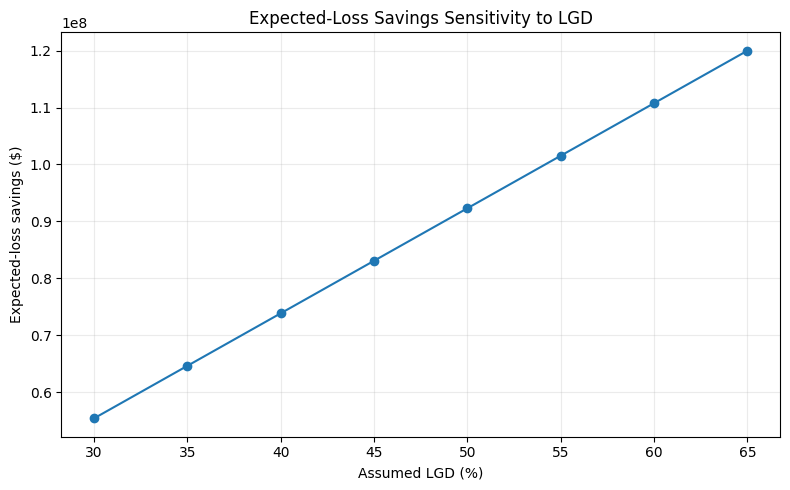

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    lgd_sensitivity["LGD"] * 100,
    lgd_sensitivity["expected_loss_savings"],
    marker="o"
)

plt.xlabel("Assumed LGD (%)")
plt.ylabel("Expected-loss savings ($)")
plt.title("Expected-Loss Savings Sensitivity to LGD")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 15. Base-case economic summary


In [17]:
print("=" * 70)
print("CREDIT POLICY — EXPECTED LOSS DECISION")
print("=" * 70)

print("\nLGD framework: Illustrative grade-based assumptions")
print(f"Fallback LGD: {BASE_LGD:.0%}")

print(
    f"Control expected loss:   ${control_el:,.0f}"
)

print(
    f"Treatment expected loss: ${treatment_el:,.0f}"
)

print(
    f"Expected-loss savings:   ${el_savings:,.0f}"
)

print(
    f"Expected-loss reduction: {el_change_pct:.2%}"
)

print(
    f"Approval-rate reduction: {approval_rate_loss:.2%}"
)

print(
    f"Additional rejections:   {additional_rejections:,.0f}"
)

print(
    f"Break-even contribution per lost approval: "
    f"${break_even_contribution:,.2f}"
)

print(
    "\nInterpretation:"
)

print(
    "The treatment generates a modeled reduction in expected credit "
    "loss under the stated LGD/EAD assumptions."
)

print(
    "However, the policy also rejects additional borrowers. The policy "
    "is economically attractive only when the value of the avoided "
    "credit loss exceeds the contribution sacrificed through those "
    "additional rejections."
)

print(
    "\nThis conclusion is conditional on the stated assumptions and "
    "should be treated as a decision framework rather than a realized "
    "profit estimate."
)

print("=" * 70)


CREDIT POLICY — EXPECTED LOSS DECISION

LGD framework: Illustrative grade-based assumptions
Fallback LGD: 45%
Control expected loss:   $865,639,452
Treatment expected loss: $781,997,145
Expected-loss savings:   $83,642,307
Expected-loss reduction: 9.66%
Approval-rate reduction: 2.42%
Additional rejections:   15,752
Break-even contribution per lost approval: $5,309.95

Interpretation:
The treatment generates a modeled reduction in expected credit loss under the stated LGD/EAD assumptions.
However, the policy also rejects additional borrowers. The policy is economically attractive only when the value of the avoided credit loss exceeds the contribution sacrificed through those additional rejections.

This conclusion is conditional on the stated assumptions and should be treated as a decision framework rather than a realized profit estimate.


## 16. Final policy framework

The project now connects the experimental and risk-modeling components:

```text
Randomized Policy Experiment
            ↓
Default reduction
            ↓
Statistical significance
            ↓
Borrower-level risk model
            ↓
PD × LGD × EAD
            ↓
Expected-loss savings
            ↓
Approval reduction
            ↓
Break-even economics
            ↓
Policy decision
```

### Key decision principle

A statistically significant reduction in default is **not sufficient** to approve the policy.

The policy should be considered economically attractive only if:

\[
Expected\ Loss\ Savings >
Value\ of\ Lost\ Approvals
\]

The current dataset does not contain enough information to estimate the full value of an approved loan. Therefore, the analysis reports a break-even contribution per lost approval and sensitivity to LGD instead of claiming a precise profit figure.

### Limitations

- LGD is assumed rather than observed.
- Loan amount is used as a proxy for EAD.
- Funding costs, interest revenue, fees, operating costs and capital charges are not modeled.
- The policy experiment and outcomes are simulated.
- The economic recommendation is therefore conditional on the stated assumptions.
